### Risks: 
1. requested libraries may not be installed in the target environment.

In [ ]:
import logging
# -------------------- LOGGER SETUP --------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.FileHandler("information_quality.log"), logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

try:
    import requests
    import csv
    import time
    import hashlib
    import csv
    import os
    from datetime import datetime, timedelta
    import csv
    import pandas as pd
    import matplotlib.pyplot as plt 
    import requests
    import logging
    from tabulate import tabulate
except Exception as e:
    logger.error(f'Exception caught when importing libraries: {e.msg}')



## Get issues lists from the repository

### Risks: Token, output_file, URL, Accessibility

 1. Hardcoded token may expired, invalid or does not have the right accesses.
 2. GitHub API rate limits may be exceeded for unauthenticated requests.
 3. Requested repositories or issues may not exist or be accessible.
 4. Network issues may prevent successful API calls.
 5. The output file may not be writable due to permission issues/cannot find the folder/file.
 6. The structure of the GitHub API response has changed.
 7. Duplicate issues may be recorded if the script is run multiple times without clearing previous data.

In [20]:
# -------------------- CONFIGURATION --------------------
OUTPUT_FILE = "pytorch_issues_last6months.csv"
TOKEN = ""
OWNER = "pytorch"
REPO = "pytorch"
since_date = (datetime.utcnow() - timedelta(days=180)).isoformat() + "Z"

base_url = f"https://api.github.com/repos/{OWNER}/{REPO}/issues"
params = {
    "state": "all",
    "since": since_date,
    "per_page": 100
}

headers = {"Accept": "application/vnd.github.v3+json"}
if TOKEN:
    headers["Authorization"] = f"token {TOKEN}"

# -------------------- FILE INTEGRITY FUNCTIONS --------------------
def is_file_accessible(path, mode='r'):
    """Check if a file is accessible in the given mode."""
    try:
        with open(path, mode):
            pass
        return True
    except (IOError, PermissionError):
        return False

def get_file_hash(path):
    """Compute a SHA256 hash of the file contents."""
    if not os.path.exists(path):
        return None
    hasher = hashlib.sha256()
    try:
        with open(path, 'rb') as f:
            while chunk := f.read(8192):
                hasher.update(chunk)
        return hasher.hexdigest()
    except Exception:
        return None

def check_file_integrity(file_path):
    """Perform integrity and accessibility checks on the output file."""
    results = []

    file_existed = os.path.exists(file_path)
    prev_hash = get_file_hash(file_path) if file_existed else None
    prev_mtime = os.path.getmtime(file_path) if file_existed else None

    # 1. Check if file is writable/accessible
    if file_existed:
        accessible = is_file_accessible(file_path, 'r+')
        results.append(["File writable", "PASS" if accessible else "FAIL"])
        if not accessible:
            raise PermissionError(f"File '{file_path}' is not accessible or writable.")
    else:
        writable_dir = os.access(os.path.dirname(os.path.abspath(file_path)) or ".", os.W_OK)
        results.append(["Directory writable", "PASS" if writable_dir else "FAIL"])
        if not writable_dir:
            raise PermissionError(f"Cannot create file '{file_path}' – directory not writable.")

    # 2. Check for unexpected modification
    if file_existed:
        time.sleep(0.1)
        current_mtime = os.path.getmtime(file_path)
        current_hash = get_file_hash(file_path)
        modified = (prev_mtime != current_mtime or prev_hash != current_hash)
        results.append(["File modified externally", "FAIL" if modified else "PASS"])
        if modified:
            raise RuntimeError(f"File '{file_path}' was modified by another process/user.")
    else:
        results.append(["File existence", "NEW FILE – will be created"])

    # 3. Create file if not exists
    if not file_existed:
        with open(file_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["id", "number", "title", "state", "user", "created_at", "updated_at", "comments", "url"])
        logger.info(f"File '{file_path}' created successfully.")

    return results



In [ ]:
# -------------------- GITHUB VALIDATION FUNCTIONS --------------------
def validate_github_token_and_url(token: str, url: str):
    """Validate GitHub token and repository API URL."""
    results = []

    logger.info("Validating GitHub token and repository URL...")
    if not url.startswith("https://api.github.com/repos/"):
        raise ValueError(f"Invalid GitHub API URL: {url}")
    results.append(["API URL format", "PASS"])

    test_headers = {"Accept": "application/vnd.github.v3+json"}
    if token:
        test_headers["Authorization"] = f"token {token}"

    try:
        response = requests.get(url, headers=test_headers, timeout=10)
    except requests.RequestException as e:
        raise ConnectionError(f"Unable to reach GitHub API: {e}")

    if response.status_code == 401:
        results.append(["Token validity", "FAIL"])
        raise PermissionError("Invalid or expired GitHub token.")
    elif response.status_code == 403 and "X-RateLimit-Remaining" in response.headers and response.headers["X-RateLimit-Remaining"] == "0":
        reset_time = int(response.headers.get("X-RateLimit-Reset", 0))
        wait_seconds = max(0, reset_time - int(time.time()))
        results.append(["Rate limit status", "FAIL"])
        raise RuntimeError(f"Rate limit exceeded. Try again in {wait_seconds} seconds.")
    elif response.status_code >= 400:
        results.append(["API response", f"FAIL ({response.status_code})"])
        raise RuntimeError(f"GitHub API error {response.status_code}: {response.text}")
    else:
        results.append(["Token validity", "PASS"])
        results.append(["API accessibility", "PASS"])

    return results

def pause_check(token: str):
    # 
    """Check GitHub API rate limit and wait if needed."""
    results = []
    logger.info("Performing pause (rate limit) check...")

    headers = {"Accept": "application/vnd.github.v3+json"}
    if token:
        headers["Authorization"] = f"token {token}"

    try:
        resp = requests.get("https://api.github.com/rate_limit", headers=headers, timeout=10)
    except requests.RequestException as e:
        raise ConnectionError(f"Unable to perform rate limit check: {e}")

    if resp.status_code == 401:
        results.append(["Rate limit endpoint", "FAIL (invalid token)"])
        raise PermissionError("GitHub token is invalid or revoked.")
    elif resp.status_code != 200:
        results.append(["Rate limit endpoint", f"FAIL ({resp.status_code})"])
        raise RuntimeError(f"Unexpected API status {resp.status_code}")

    data = resp.json()
    remaining = data["rate"]["remaining"]
    reset_time = int(data["rate"]["reset"])

    if remaining == 0:
        wait_seconds = max(0, reset_time - int(time.time()))
        results.append(["Rate limit availability", "FAIL (waiting)"])
        logger.warning(f"Rate limit reached. Sleeping for {wait_seconds} seconds...")
        time.sleep(wait_seconds + 1)
    else:
        results.append(["Rate limit availability", f"PASS ({remaining} requests left)"])

    return results

In [22]:
# -------------------- HELPER FUNCTIONS --------------------
def load_existing_issues(file_path):
    """Load existing issues from CSV file if present."""
    if not os.path.exists(file_path):
        return []

    existing = []
    with open(file_path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                row["id"] = int(row["id"])
            except (ValueError, TypeError):
                continue
            existing.append(row)
    logger.info(f"Loaded {len(existing)} existing issues from {file_path}")
    return existing

def get_latest_issue_date(issues):
    """Get the most recent 'created_at' date from existing issues."""
    if not issues:
        return None
    try:
        latest = max(datetime.fromisoformat(i["created_at"].replace("Z", "+00:00")) for i in issues)
        return latest
    except Exception:
        return None

def check_duplicates(issues):
    """Check for duplicate issue IDs."""
    ids = [i["id"] for i in issues]
    dup_ids = {i for i in ids if ids.count(i) > 1}
    return list(dup_ids)

def fetch_new_issues(since_date, existing_ids):
    """Fetch new GitHub issues created after the given date."""
    issues = []
    page = 1
    logger.info(f"Fetching issues created since {since_date}...")

    params = {
        "state": "all",
        "since": since_date,
        "per_page": 100,
        "page": page,
    }

    while True:
        response = requests.get(base_url, headers=headers, params=params, timeout=15)
        if response.status_code != 200:
            logger.error(f"Error {response.status_code}: {response.text}")
            break

        data = response.json()
        if not data:
            break

        new_batch = []
        for issue in data:
            if "pull_request" in issue:
                continue
            if issue["id"] not in existing_ids:
                new_batch.append({
                    "id": issue["id"],
                    "number": issue["number"],
                    "title": issue["title"],
                    "state": issue["state"],
                    "user": issue["user"]["login"],
                    "created_at": issue["created_at"],
                    "updated_at": issue["updated_at"],
                    "comments": issue["comments"],
                    "url": issue["html_url"]
                })

        if new_batch:
            issues.extend(new_batch)
            logger.info(f"Fetched page {page}: {len(new_batch)} new issues found.")
        else:
            logger.info(f"Fetched page {page}: no new issues found.")

        # Stop if less than 100 results
        if len(data) < 100:
            break

        page += 1
        params["page"] = page

    logger.info(f"Total new issues fetched: {len(issues)}")
    return issues

def append_issues_to_csv(file_path, new_issues):
    """Append new issues to the CSV without overwriting or duplicating header."""
    if not new_issues:
        logger.info("No new issues to append.")
        return

    file_exists = os.path.exists(file_path)
    write_header = not file_exists or os.stat(file_path).st_size == 0

    with open(file_path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=new_issues[0].keys())
        if write_header:
            writer.writeheader()
        writer.writerows(new_issues)

    logger.info(f"Appended {len(new_issues)} new issues to {file_path}")



In [ ]:
# -------------------- MAIN EXECUTION --------------------
if __name__ == "__main__":
    logger.info("Starting integrity and accessibility checks...")

    integrity_results = []
    data_access_results = []

    try:
        integrity_results = check_file_integrity(OUTPUT_FILE)
        data_access_results += validate_github_token_and_url(TOKEN, base_url)
        data_access_results += pause_check(TOKEN)
        logger.info("All checks passed successfully.")
    except Exception as e:
        logger.error(f"Validation failed: {e}")

    # -------------------- QUALITY CHECKLIST TABLE --------------------
    table_data = [
        ["INTEGRITY OF OUTPUT FILE", "", ""],
        *[[f"  - {r[0]}", r[1], "OK" if "PASS" in r[1] else "FAIL"] for r in integrity_results],
        ["ACCESSIBILITY OF DATA", "", ""],
        *[[f"  - {r[0]}", r[1], "OK" if "PASS" in r[1] else "FAIL"] for r in data_access_results],
    ]

    checklist_table = tabulate(table_data, headers=["Check", "Result", "Status"], tablefmt="grid")
    logger.info("\n" + checklist_table)
    
    logger.info("Starting incremental GitHub issue synchronization...")

    checklist = []

    try:
        existing_issues = load_existing_issues(OUTPUT_FILE)
        existing_ids = {i["id"] for i in existing_issues}

        # Determine fetch start date
        if existing_issues:
            latest_issue_date = get_latest_issue_date(existing_issues)
            since_date = latest_issue_date.isoformat().replace("+00:00", "Z") if latest_issue_date else (
                datetime.utcnow() - timedelta(days=90)).isoformat() + "Z"
            logger.info(f"Detected existing data. Fetching only issues newer than {since_date}.")
        else:
            since_date = (datetime.utcnow() - timedelta(days=90)).isoformat() + "Z"
            logger.info(f"No existing data. Fetching issues for the last 3 months since {since_date}.")

        # 1. Check for duplicates
        duplicates = check_duplicates(existing_issues)
        checklist.append(["Duplicate issue IDs", "PASS" if not duplicates else f"FAIL ({len(duplicates)} found)"])

        # 2. Fetch new issues only
        new_issues = fetch_new_issues(since_date, existing_ids)
        checklist.append(["New issues fetched", f"PASS ({len(new_issues)} new)" if new_issues else "PASS (no new issues)"])

        # 3. Append new data
        append_issues_to_csv(OUTPUT_FILE, new_issues)

        # 4. Basic missing record check
        total_unique_ids = len(set(i["id"] for i in existing_issues + new_issues))
        if len(existing_issues) + len(new_issues) > total_unique_ids:
            checklist.append(["Missing record consistency", "FAIL (ID mismatch)"])
        else:
            checklist.append(["Missing record consistency", "PASS"])

        logger.info("Data synchronization completed successfully.")

    except Exception as e:
        logger.error(f"Process failed: {e}")
        checklist.append(["Overall process", f"FAIL ({e})"])

    # -------------------- QUALITY CHECKLIST TABLE --------------------
    table = tabulate(
        [["DATA QUALITY CHECKS", "", ""]] +
        [[f"  - {item[0]}", item[1], "OK" if "PASS" in item[1] else "FAIL"] for item in checklist],
        headers=["Check", "Result", "Status"],
        tablefmt="grid"
    )
    logger.info("\n" + table)

## Summary date in the last 8 weeks

### Risks:
1. The CSV file may not exist or be accessible.
2. The date format in the CSV may not match the expected ISO format.
3. Issues duplication, missing or misclassification due to data inconsistencies.
4. The date range calculation may not align with the intended analysis period.

In [ ]:
## Risks:
# 1. The CSV file may not exist or be accessible.
# 2. The date format in the CSV may not match the expected ISO format.
# 3. Issues duplication, missing or misclassification due to data inconsistencies.
# 4. The date range calculation may not align with the intended analysis period.

with open(OUTPUT_FILE, "r", newline="", encoding="utf-8") as f:
    reader = list(csv.DictReader(f))


today = datetime.utcnow().date()
monday_this_week = today - timedelta(days=today.weekday())
start_date = monday_this_week - timedelta(weeks=7)

weekly_counts = []
for i in range(8):
    week_start = start_date + timedelta(weeks=i)
    week_end = week_start + timedelta(days=6)
    if week_end > today:
        week_end = today
    weekly_counts.append({
        "Week": f"{week_start} → {week_end}",
        "Open Issues": 0,
        "Closed Issues": 0
    })

for issue in reader:
    try:
        created_at = datetime.fromisoformat(str(issue["created_at"])).date()
    except Exception:
        continue

    state = issue.get("state", "").lower().strip()

    if created_at < start_date or created_at > today:
        continue

    for week in weekly_counts:
        week_start_str, week_end_str = week["Week"].split(" → ")
        week_start = datetime.strptime(week_start_str, "%Y-%m-%d").date()
        week_end = datetime.strptime(week_end_str, "%Y-%m-%d").date()
        if week_start <= created_at <= week_end:
            if state == "closed":
                week["Closed Issues"] += 1
            else:
                week["Open Issues"] += 1
            break

df_weeks = pd.DataFrame(weekly_counts)

In [44]:
df_weeks

,Week,Open Issues,Closed Issues
0,2025-08-25 → 2025-08-31,51,78
1,2025-09-01 → 2025-09-07,56,85
2,2025-09-08 → 2025-09-14,91,84
3,2025-09-15 → 2025-09-21,63,62
4,2025-09-22 → 2025-09-28,100,54
5,2025-09-29 → 2025-10-05,78,40
6,2025-10-06 → 2025-10-12,73,30
7,2025-10-13 → 2025-10-18,107,31


## Predict next week's value

### Risks:
1. Don't have history data to make reliable predictions.
2. The prediction is not successful if the data is missing or mathematically invalid.

In [ ]:

# Predict next week's open and closed issues (average of last 2 weeks)
last_2_weeks = df_weeks.tail(2)
predicted_open = last_2_weeks['Open Issues'].mean()
predicted_closed = last_2_weeks['Closed Issues'].mean()

print(f"Predicted Open Issues for Next Week: {predicted_open:.2f}")
print(f"Predicted Closed Issues for Next Week: {predicted_closed:.2f}")

# Define warning rules
warning_conditions = {
    "A": "Predicted open issues exceed 80 or predicted closed issues are below 30.",
    "B": "The difference between predicted open and closed issues exceeds 90.",
    "C": "Predicted open issues show an increasing trend while predicted closed issues show a decreasing trend."
}

# Check for warnings
triggered_warnings = []

if predicted_open > 80 or predicted_closed < 30:
    triggered_warnings.append("A")

if (predicted_open - predicted_closed) > 90:
    triggered_warnings.append("B")

if (predicted_open > last_2_weeks['Open Issues'].iloc[-1]) and \
   (predicted_closed < last_2_weeks['Closed Issues'].iloc[-1]):
    triggered_warnings.append("C")

# Print triggered warnings (full messages)
if triggered_warnings:
    print("\n Warning conditions triggered:")
    for code in triggered_warnings:
        print(f" - Type {code}: {warning_conditions[code]}")
else:
    print("\n No warning conditions triggered.")

# Add prediction + warning types to DataFrame
new_row = pd.DataFrame([{
    "Week": "Next Week",
    "Open Issues": round(predicted_open, 2),
    "Closed Issues": round(predicted_closed, 2),
    # Only store the type codes (e.g. "A,B,C")
    "Warning_type": ",".join(triggered_warnings) if triggered_warnings else None
}])

df_weeks = pd.concat([df_weeks, new_row], ignore_index=True)

df_weeks


Predicted Open Issues for Next Week: 90.00
Predicted Closed Issues for Next Week: 30.50

 Warning conditions triggered:
 - Type A: Predicted open issues exceed 80 or predicted closed issues are below 30.


,Week,Open Issues,Closed Issues,Warning_type
0,2025-08-25 → 2025-08-31,51.0,78.0,NaN
1,2025-09-01 → 2025-09-07,56.0,85.0,NaN
2,2025-09-08 → 2025-09-14,91.0,84.0,NaN
3,2025-09-15 → 2025-09-21,63.0,62.0,NaN
4,2025-09-22 → 2025-09-28,100.0,54.0,NaN
5,2025-09-29 → 2025-10-05,78.0,40.0,NaN
6,2025-10-06 → 2025-10-12,73.0,30.0,NaN
7,2025-10-13 → 2025-10-18,107.0,31.0,NaN
8,Next Week,90.0,30.5,A


## Visualize the summarized data

### Risks:
1. The data may not be in the expected format for plotting.
2. There might be duplicated "next week" entries if the script is run multiple times without clearing previous data.

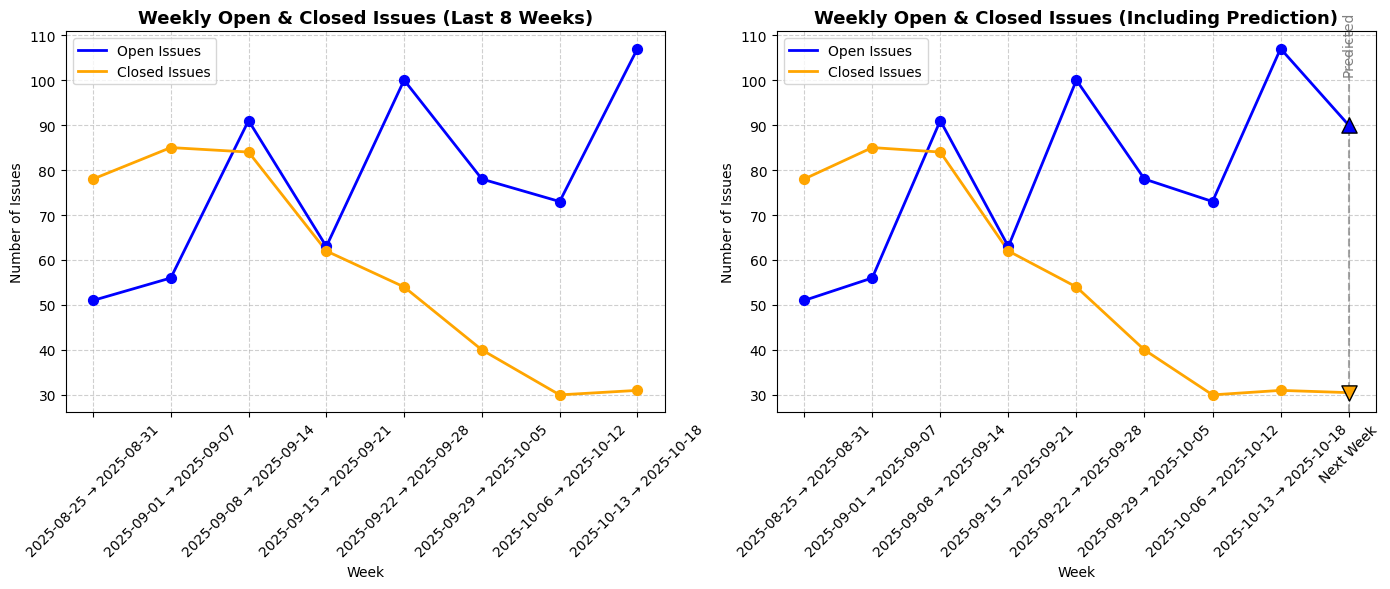

In [ ]:
df_actual = df_weeks.iloc[:-1]   
df_pred = df_weeks            


def plot_issues(df, title, include_prediction=False):
    weeks = df['Week']
    open_issues = df['Open Issues']
    closed_issues = df['Closed Issues']
    warnings = df.get('Warning_type', pd.Series([None] * len(df)))

    plt.plot(weeks, open_issues, color='blue', label='Open Issues', linewidth=2)
    plt.plot(weeks, closed_issues, color='orange', label='Closed Issues', linewidth=2)


    for i, week in enumerate(weeks):
        if pd.notna(warnings[i]) and warnings[i] != "":
            plt.scatter(week, open_issues[i], color='blue', s=120, marker='^', edgecolor='black', zorder=5)
            plt.scatter(week, closed_issues[i], color='orange', s=120, marker='v', edgecolor='black', zorder=5)
        else:
            plt.scatter(week, open_issues[i], color='blue', s=50, marker='o', zorder=4)
            plt.scatter(week, closed_issues[i], color='orange', s=50, marker='o', zorder=4)

    if include_prediction:
        plt.axvline(x=weeks.iloc[-1], color='gray', linestyle='--', alpha=0.7)
        plt.text(weeks.iloc[-1], max(open_issues.max(), closed_issues.max()) * 0.95,
                 "Predicted", rotation=90, color='gray', fontsize=10, ha='center')

    plt.title(title, fontsize=13, weight='bold')
    plt.xlabel('Week')
    plt.ylabel('Number of Issues')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plot_issues(df_actual, "Weekly Open & Closed Issues (Last 8 Weeks)")


plt.subplot(1, 2, 2)
plot_issues(df_pred, "Weekly Open & Closed Issues (Including Prediction)", include_prediction=True)

plt.tight_layout()
plt.show()
